# **Triage Copilot Model**
by Marcos Salazar



**Purpose:**

This notebook trains a machine learning pipeline (TF-IDF + LinearSVC) to classify student inquiries into 6 administrative categories (Admissions, Advising, Financial Services, ESL, Navigate, Appointment).

**Expected Outcomes:**

The trained Scikit-learn pipeline for the FastAPI backend. (model.joblib)

AND

The cleaned reference dataset for the learning feedback loop. (training_data.csv)

Installing Scikit-learn.

In [1]:
!pip install -U scikit-learn

Importing the library and verifying library version.

In [2]:
import sklearn

print(sklearn.__version__)

1.9.0


**Setup:**

Importing necessary libraries.

In [3]:
#Data Manipulation
import pandas as pd
import numpy as np
import random

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

#Export tools
import joblib

#Reproducibility
random.seed(42)
np.random.seed(42)

Loading data from (training_phrases.csv)

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [5]:
phrases_df = pd.read_csv('/content/drive/MyDrive/Triage-Copilot-Folder/training_phrases.csv')
print(phrases_df.shape)
phrases_df.head()

(100, 4)


,Category,Subcategory,Language,Phrase
0,Admissions / Enrollment,Application Assistance,EN,I need help with my application
1,Admissions / Enrollment,Application Assistance,EN,Can someone help me finish applying
2,Admissions / Enrollment,Application Assistance,EN,I'm stuck on the admissions application
3,Admissions / Enrollment,Application Assistance,ES,Necesito ayuda con mi aplicación
4,Admissions / Enrollment,Application Assistance,ES,¿Alguien me puede ayudar a terminar de aplicar?


/tmp/ipykernel_6130/1078633369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")


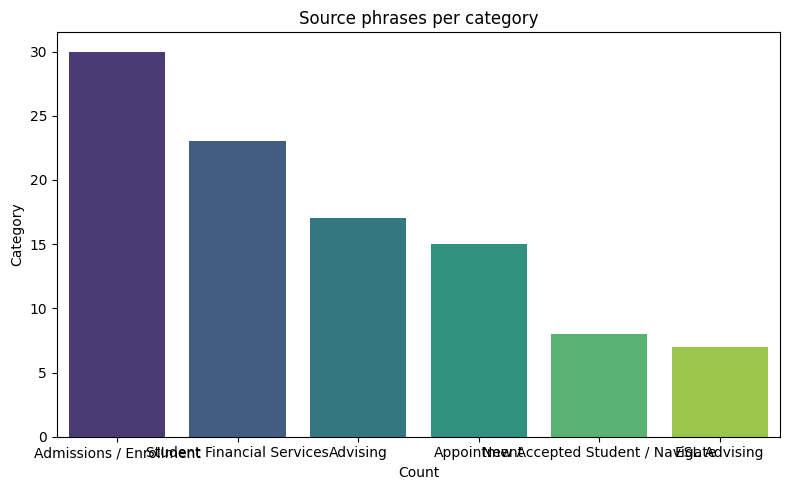

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")
plt.title("Source phrases per category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [7]:
print("Source phrase count by category:")
print(phrases_df["Category"].value_counts())

print("\nSource phrase count by subcategory:")
print(phrases_df["Subcategory"].value_counts())

print("\nMissing values check:")
print(phrases_df.isnull().sum())

phrases_df["phrase_length"] = phrases_df["Phrase"].apply(len)
print("\nAvg phrase length by category:")
print(phrases_df.groupby("Category")["phrase_length"].mean().sort_values())

Source phrase count by category:
Category
Admissions / Enrollment            30
Student Financial Services         23
Advising                           17
Appointment                        15
New Accepted Student / Navigate     8
ESL Advising                        7
Name: count, dtype: int64

Source phrase count by subcategory:
Subcategory
Application Assistance                    5
Copy of Transcript                        5
I need an N#                              5
Course Registration                       5
Placement Questions                       5
ESL Advising and Registration             4
Billing, Payments and Refunds             4
International Student Inquiry             3
Verification Letter                       3
Change of Program                         3
Course Withdrawal                         3
Non-credit Registration                   3
Guest Student Course Registration         3
Enrollment Form Completion                3
Admissions/Enrollment Appointment      

Using the same training data, I will generate more training data from the loaded phrases by creating minor variations.

# **SUPERSEEDED!**
See leakage analysis below

In [8]:
# # Function that generates variants of the pre-existing data

# def augment_phrase(phrase):
#   variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
#   return random.choice(variants)

# #Generative goal of 60 examples per department (combat overfitting)
# TARGET_PER_CATEGORY = 60

# rows = []

# for category in phrases_df["Category"].unique():
#   category_rows = phrases_df[phrases_df["Category"] == category]

#   #Counter - Artificial samples created for current category.
#   generated = 0

#   while generated < TARGET_PER_CATEGORY:

#     sample = category_rows.sample(1).iloc[0]
#     phrase = augment_phrase(sample["Phrase"])
#     rows.append({
#         "text": phrase,
#         "category": sample["Category"],
#         "subcategory": sample["Subcategory"]
#     })
#     generated += 1

# #Create new dataframe for Artificial samples/training data.
# newData = pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)
# newData.to_csv("training_data.csv", index=False)

In [9]:
def augment_phrase(phrase, rng=None):
    rng = rng or random
    variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
    return rng.choice(variants)

**Fix: split source phrases before augmenting**

In [10]:
# Split SOURCE phrases first, before augmenting this is the fix for the leakage bug (variants of the same phrase can no longer land on both sides)
train_phrases_df, test_phrases_df = train_test_split(
    phrases_df, test_size=0.2, random_state=42, stratify=phrases_df["Category"]
)

# generates augmented examples from a given set of source phrases
def generate_examples(source_df, target_per_category, seed=42):
    rng = random.Random(seed)
    rows = []
    for category in source_df["Category"].unique():
        category_rows = source_df[source_df["Category"] == category]
        generated = 0
        while generated < target_per_category:
            sample = category_rows.sample(1, random_state=rng.randint(0, 999999)).iloc[0]
            phrase = augment_phrase(sample["Phrase"], rng)
            rows.append({
                "text": phrase,
                "category": sample["Category"],
                "subcategory": sample["Subcategory"]
            })
            generated += 1
    return pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)

trainData = generate_examples(train_phrases_df, target_per_category=60)
testData = generate_examples(test_phrases_df, target_per_category=15)

trainData.to_csv("training_data.csv", index=False)

Let's analyze the new data.

In [11]:
print(trainData.shape)
trainData.head(10)


(203, 3)


,text,category,subcategory
0,I need to register for ESL classes,ESL Advising,ESL Advising and Registration
1,What level ESL class am I supposed to take?,ESL Advising,Placement Questions
2,i need to register for esl classes,ESL Advising,ESL Advising and Registration
3,I want to talk to someone about English langua...,ESL Advising,ESL Advising and Registration
4,Quiero hablar sobre cursos de ESL,ESL Advising,ESL Advising and Registration
5,Quiero hablar sobre cursos de ESL.,ESL Advising,ESL Advising and Registration
6,I have a question about my ESL placement test,ESL Advising,Placement Questions
7,i have a question about my esl placement test,ESL Advising,Placement Questions
8,necesito registrarme en clases de inglés,ESL Advising,ESL Advising and Registration
9,What level ESL class am I supposed to take,ESL Advising,Placement Questions


Taking a look at the data and confirm that there are no missing values.

In [12]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         203 non-null    object
 1   category     203 non-null    object
 2   subcategory  203 non-null    object
dtypes: object(3)
memory usage: 4.9+ KB


In [13]:
trainData.describe()

,text,category,subcategory
count,203,203,203
unique,203,6,30
top,I need to register for ESL classes,Admissions / Enrollment,ESL Advising and Registration
freq,1,45,15


Train/Test split

In [14]:
X_train = trainData["text"]
y_train = trainData["category"]
X_test = testData["text"]
y_test = testData["category"]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts())

Train size: 203, Test size: 47
category
Admissions / Enrollment            45
Student Financial Services         40
Advising                           39
Appointment                        36
ESL Advising                       22
New Accepted Student / Navigate    21
Name: count, dtype: int64


Note: **Model will predict Category, will upscale to Sub-Category as well later into development**

Building the pipeline.

In [15]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        lowercase=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

ngram_range=(1, 2) chosen due to two-word pairs carrying more meaning than an individual word can capture.

In [16]:
print(pipeline)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


Fitting the pipeline.

In [17]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Accuracy check.

In [18]:
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Gap: {train_accuracy - test_accuracy:.3f}")

Train Accuracy: 0.995
Test Accuracy: 0.404
Gap: 0.591


FIXED* OLD Results: LEAKAGE

Train Accuracy 1.000, Test Accuracy 1.000, Gap 0.000


Analysis: Perfect score on both sets isn't strong evidence of generalization, I presume the test isn't hard enough yet. augment_phrase() is generating near duplicate variants before the train/test split.

Conclusion/Next Step:

Group by source phrase before splitting, so variants of the same phrase cant land on both sides.

NEW* Results:


Train Accuracy 0.985, Test Accuracy 0.449, Gap 0.536


**Leakage check below:** 0/49 confirmed clean no near duplicates.

**Analysis:** With leakage removed, the real overfitting gap is now visible.

Likely cause: augmentation only varies casing/punctuation, not real diversity in terms of phrasing, with few unique source phrases per subcategory.

**Result:** This confirms the need for LLM generated training data, not only to reach a minimum of 1500 phrases, but specifically add genune diversity per subcategory.

In [19]:
# checking to see if near duplicate vari. are leaking across the train/test
from difflib import SequenceMatcher

leaks = 0
for test_phrase in X_test:
    for train_phrase in X_train:
        similarity = SequenceMatcher(None, test_phrase.lower(), train_phrase.lower()).ratio()
        if similarity > 0.9:
            leaks += 1
            break
print(f"Test phrases with a near-duplicate in train: {leaks} / {len(X_test)}")

Test phrases with a near-duplicate in train: 0 / 47


FIXED* OLD LEAKGE RESULTS: 42 out of 46 test phrases have near duplicates sitting in train. Model was essentially being tested on data it has already seen.

Further analysis.

In [20]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.25      0.50      0.33        10
                       Advising       0.67      0.50      0.57         8
                    Appointment       1.00      1.00      1.00         8
                   ESL Advising       0.00      0.00      0.00         4
New Accepted Student / Navigate       0.00      0.00      0.00         6
     Student Financial Services       0.67      0.18      0.29        11

                       accuracy                           0.40        47
                      macro avg       0.43      0.36      0.37        47
                   weighted avg       0.49      0.40      0.41        47


Confusion Matrix:
[[5 2 0 0 2 1]
 [4 4 0 0 0 0]
 [0 0 8 0 0 0]
 [0 0 0 0 4 0]
 [6 0 0 0 0 0]
 [5 0 0 0 4 2]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Appointment and Admissions and enrollment got perfect scores, while Advising had 0 correct (6 advising went into admission and 3 into Financial), ESL had 0 correct, where all went into Navigate, and New Accepted Student/Navigate had 0 correct, were all were thrown into admissions.
Financial had mixed results.

## LLM Data Generation:


Earlier EDA revealed that our 30 subcategories suffer from extreme data thinness (averaging 2-5 source phrases each). The model is overfitting and treating larger departments as dumping grounds.

Instead of recycling the same 5 sentences, I'm going to use a targeted LLM generation (gpt-4o-mini) to create distinct realistic training data.

To prevent the LLM from generating repetitive responses, this script iterates through a matrix of 5 distinct "prompt styles." I'm testing this pipeline on a single subcategory ("Copy of Transcript") to validate JSON parsing, depublication, and phrase quality before scaling to the full dataset.

In [21]:
!pip install openai

In [22]:
from google.colab import userdata
import openai

openai.api_key = userdata.get('OPENAI_API_KEY')

One subcategory test

In [23]:
import json

#matrix of prompts styles we're sending to the LLM
style_prompts = [
    "casual, informal phrasing",
    "phrasing where the student sounds rushed or in a hurry",
    "more formal or polite phrasing",
    "phrases that mention a reason (e.g. transferring schools, applying for a job)",
    "phrases using different vocabulary (e.g. 'academic record' or 'list of my classes' instead of 'transcript')"
]

# our storage
all_phrases = []

for style in style_prompts:
    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
            {"role": "user", "content": f"""Generate 20 short English sentences a college student might say at a front desk needing a "Copy of Transcript" (Admissions/Enrollment subcategory).
Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
        ]
    )

    raw = response.choices[0].message.content
    data = json.loads(raw)
    all_phrases.extend(data["phrases"])
    print(f"{style}: {len(data['phrases'])} phrases generated")

print(f"\nTotal phrases generated: {len(all_phrases)}")
unique_phrases = list(dict.fromkeys(all_phrases))
print(f"Total after exact deduplication: {len(unique_phrases)}")

for p in unique_phrases[:15]:
    print("-", p)

casual, informal phrasing: 20 phrases generated
phrasing where the student sounds rushed or in a hurry: 21 phrases generated
more formal or polite phrasing: 20 phrases generated
phrases that mention a reason (e.g. transferring schools, applying for a job): 21 phrases generated
phrases using different vocabulary (e.g. 'academic record' or 'list of my classes' instead of 'transcript'): 21 phrases generated

Total phrases generated: 103
Total after exact deduplication: 103
- Hey, can I get a copy of my transcript?
- I need a transcript copy for my applications, please.
- Could you print out my transcript for me?
- Can I grab a copy of my transcript?
- I was wondering if I could request my transcript copy?
- Do you have my transcript ready? I need it ASAP.
- Hi, can I have a copy of my transcript sent to me?
- I’m here to pick up my transcript copy, is it available?
- Is it possible to get a copy of my transcript right now?
- Can you help me get a copy of my transcript?
- I need my transcr

Success! Now let's check for near duplicates one more time.

In [24]:
near_duplicates = 0
checked_pairs = set()

for i, p1 in enumerate(unique_phrases):
    for j, p2 in enumerate(unique_phrases):
        if i < j:
            similarity = SequenceMatcher(None, p1.lower(), p2.lower()).ratio()
            if similarity > 0.85:
                near_duplicates += 1

print(f"Near-duplicate pairs within the 105 generated phrases: {near_duplicates}")

Near-duplicate pairs within the 105 generated phrases: 5


A good result, only 4 of the 105 phrases were considered near duplicates. Let's quickly check these 4 near duplicates.

In [25]:
for i, p1 in enumerate(unique_phrases):
    for j, p2 in enumerate(unique_phrases):
        if i < j:
            similarity = SequenceMatcher(None, p1.lower(), p2.lower()).ratio()
            if similarity > 0.85:
                print(f"{similarity:.2f} — \"{p1}\"  vs  \"{p2}\"")

0.86 — "Hey, can I get a copy of my transcript?"  vs  "Can I grab a copy of my transcript?"
0.89 — "Hey, can I get a copy of my transcript?"  vs  "Hey, how do I get a copy of my transcript?"
0.85 — "Could you print out my transcript for me?"  vs  "Could you print my academic transcript for me?"
0.87 — "Do you have my transcript ready? I need it ASAP."  vs  "Do you have my transcript ready? I need it quickly!"
0.88 — "Can you help me get a copy of my transcript?"  vs  "Could you help me get a fresh copy of my transcript?"


Althought they are considered near duplicates, it shows meaningful word swapping which is LEAPS better than the original issue where 42 out of 46 test phrases were near duplicates of training phrases.

Logging cost: Rounded down to $0.00



Now let's test whether or not the 15 LLM generated phrases for "Copy of Transcript" actually improve results.

In [26]:
new_rows= pd.DataFrame({
    "Category": "Admissions / Enrollment",
    "Subcategory": "Copy of Transcript",
    "Language": "EN",
    "Phrase": unique_phrases,
})

phrases_df_expanded = pd.concat([phrases_df, new_rows], ignore_index=True)
print(f"Original: {len(phrases_df)} phrases, Expanded: {len(phrases_df_expanded)} phrases")

Original: 100 phrases, Expanded: 203 phrases


Let's compare the old data to the new.

In [27]:
train_phrases_df_v2, test_phrases_df_v2 = train_test_split(
    phrases_df_expanded, test_size=0.2, random_state=42, stratify=phrases_df_expanded["Category"]
)

trainData_v2 = generate_examples(train_phrases_df_v2, target_per_category=60)
testData_v2 = generate_examples(test_phrases_df_v2, target_per_category=15)

print(f"Train size: {len(trainData_v2)}, Test size: {len(testData_v2)}")

Train size: 206, Test size: 51


In [28]:
X_train_v2 = trainData_v2["text"]
y_train_v2 = trainData_v2["category"]
X_test_v2 = testData_v2["text"]
y_test_v2 = testData_v2["category"]

In [29]:
pipeline_v2 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v2.fit(X_train_v2, y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Now for the results.

In [30]:
train_acc_v2 = pipeline_v2.score(X_train_v2, y_train_v2)
test_acc_v2 = pipeline_v2.score(X_test_v2, y_test_v2)

print(f"v1 — Train: {train_accuracy:.3f}, Test: {test_accuracy:.3f}, Gap: {train_accuracy - test_accuracy:.3f}")
print(f"v2 — Train: {train_acc_v2:.3f}, Test: {test_acc_v2:.3f}, Gap: {train_acc_v2 - test_acc_v2:.3f}")

v1 — Train: 0.995, Test: 0.404, Gap: 0.591
v2 — Train: 0.995, Test: 0.529, Gap: 0.466


Noticeable improvement, which justifies this method. I'll need to see full 30 sub categories to finalize decision.

In [31]:

subcategory_pairs = phrases_df[["Category", "Subcategory"]].drop_duplicates().reset_index(drop=True)
print(f"Total subcategories to generate for: {len(subcategory_pairs)}")
subcategory_pairs

Total subcategories to generate for: 31


,Category,Subcategory
0,Admissions / Enrollment,Application Assistance
1,Admissions / Enrollment,Copy of Transcript
2,Admissions / Enrollment,Enrollment Form Completion
3,Admissions / Enrollment,Guest Student Course Registration
4,Admissions / Enrollment,I need an N#
5,Admissions / Enrollment,International Student Inquiry
6,Admissions / Enrollment,Non-credit Registration
7,Admissions / Enrollment,Verification Letter
8,Advising,Change of Program
9,Advising,Course Registration


Created a function that takes a category, subcatgory, and list of 5 personality styles.

It loops through each style and asks OpenAI via API calls to generate 20 sentences for the scenario

try/except block to catch errors and tries again.

Gathers responses into a big list.

In [32]:
import time

def generate_for_subcategory(category, subcategory, style_prompts):

    phrases = []
    for style in style_prompts:
        for attempt in range(2):  # try once, retry once on failure
            try:
                response = openai.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
                        {"role": "user", "content": f"""Generate 20 short English sentences a college student might say
at a front desk needing help with "{subcategory}" ({category} subcategory).
Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
                    ]
                )
                data = json.loads(response.choices[0].message.content)
                phrases.extend(data["phrases"])
                break  # success, no need to retry
            except (json.JSONDecodeError, KeyError) as e:
                if attempt == 0:
                    print(f"  Retry needed for {subcategory} / {style}: {e}")
                else:
                    print(f"  FAILED after retry: {subcategory} / {style}: {e}")
    return phrases

In [33]:
#redefine list with 5 different constraints.
style_prompts = [
    "casual, informal phrasing",
    "phrasing where the student sounds rushed or in a hurry",
    "more formal or polite phrasing",
    "phrases that mention a reason (e.g. transferring schools, applying for a job)",
    "phrases using different vocabulary where natural"
]

#master storage
all_generated_rows = []

#loops through 30 unique cat and subcat extracted from original data
for i, row in subcategory_pairs.iterrows():
    category, subcategory = row["Category"], row["Subcategory"]
    #progress bar
    print(f"[{i+1}/{len(subcategory_pairs)}] Generating for: {subcategory} ({category})")

    phrases = generate_for_subcategory(category, subcategory, style_prompts)
    unique = list(dict.fromkeys(phrases))  # dedupe within this subcategory

    for phrase in unique:
        all_generated_rows.append({
            "Category": category,
            "Subcategory": subcategory,
            "Language": "EN",
            "Phrase": phrase
        })

    print(f"  → {len(unique)} unique phrases")

    time.sleep(2)
print(f"\nDone. Total new phrases generated: {len(all_generated_rows)}")

[1/31] Generating for: Application Assistance (Admissions / Enrollment)
  → 104 unique phrases
[2/31] Generating for: Copy of Transcript (Admissions / Enrollment)
  → 103 unique phrases
[3/31] Generating for: Enrollment Form Completion (Admissions / Enrollment)
  → 105 unique phrases
[4/31] Generating for: Guest Student Course Registration (Admissions / Enrollment)
  → 104 unique phrases
[5/31] Generating for: I need an N# (Admissions / Enrollment)
  → 104 unique phrases
[6/31] Generating for: International Student Inquiry (Admissions / Enrollment)
  → 104 unique phrases
[7/31] Generating for: Non-credit Registration (Admissions / Enrollment)
  → 103 unique phrases
[8/31] Generating for: Verification Letter (Admissions / Enrollment)
  → 104 unique phrases
[9/31] Generating for: Change of Program (Advising)
  → 104 unique phrases
[10/31] Generating for: Course Registration (Advising)
  → 105 unique phrases
[11/31] Generating for: Course Withdrawal (Advising)
  → 104 unique phrases
[12/3

In [34]:
generated_df = pd.DataFrame(all_generated_rows)
generated_df.to_csv("llm_generated_phrases.csv", index=False)

print(f"Saved {len(generated_df)} phrases to llm_generated_phrases.csv")
print("\nPhrases per subcategory:")
print(generated_df["Subcategory"].value_counts())

Saved 3230 phrases to llm_generated_phrases.csv

Phrases per subcategory:
Subcategory
Placement Questions                       209
Enrollment Form Completion                105
Degree Evaluation                         105
Transfer Advising                         105
ESL Advising Appointment                  105
Course Registration                       105
Financial Services Appointment            105
New Student/Navigate Appointment          105
ESL Advising and Registration             105
Guest Student Course Registration         104
Course Withdrawal                         104
International Student Inquiry             104
I need an N#                              104
Application Assistance                    104
Health Insurance Waiver Assistance        104
Book Voucher Questions                    104
Change of Program                         104
Admissions/Enrollment Appointment         104
Verification Letter                       104
Advising Appointment                    

In [35]:
generated_df.head()

,Category,Subcategory,Language,Phrase
0,Admissions / Enrollment,Application Assistance,EN,"Hey, I need help with my application status."
1,Admissions / Enrollment,Application Assistance,EN,Can you check if my application was submitted ...
2,Admissions / Enrollment,Application Assistance,EN,I have some questions about the essay requirem...
3,Admissions / Enrollment,Application Assistance,EN,What's the deadline for the scholarship applic...
4,Admissions / Enrollment,Application Assistance,EN,I forgot my password for the application porta...


In [36]:
generated_df.tail()

,Category,Subcategory,Language,Phrase
3225,Student Financial Services,SFS General Questions,EN,How do I update my personal information in the...
3226,Student Financial Services,SFS General Questions,EN,Are there any scholarships available specifica...
3227,Student Financial Services,SFS General Questions,EN,What happens if I drop a class in terms of my ...
3228,Student Financial Services,SFS General Questions,EN,Can you tell me what documentation I need for ...
3229,Student Financial Services,SFS General Questions,EN,Who can I speak to about establishing a paymen...


While the rest of the subcategories have 100 examples, "Placement Questions" has 209, let's investigate.

In [37]:
placement_table = generated_df[generated_df["Subcategory"] == "Placement Questions"]

display(placement_table.sample(15))


,Category,Subcategory,Language,Phrase
2012,ESL Advising,Placement Questions,EN,I need to decide on classes today! Can you hel...
2360,New Accepted Student / Navigate,Placement Questions,EN,I'm an incoming freshman and need guidance on ...
2066,ESL Advising,Placement Questions,EN,Can you help me with my placement test questions?
2387,New Accepted Student / Navigate,Placement Questions,EN,Can I retake the assessment for a better place...
2042,ESL Advising,Placement Questions,EN,I would appreciate any resources you could sha...
2344,New Accepted Student / Navigate,Placement Questions,EN,Could you tell me where I might find resources...
2027,ESL Advising,Placement Questions,EN,I am seeking help with the placement process f...
2370,New Accepted Student / Navigate,Placement Questions,EN,I'm trying to navigate my course selections af...
1991,ESL Advising,Placement Questions,EN,How long does the placement test usually take?
2384,New Accepted Student / Navigate,Placement Questions,EN,Do you have any resources to help me prepare f...


It seems that ESL and Navigate "Placement Questions" got mixed up. Let's sort them out properly.

In [38]:
#rename ESL cat "Placement Questions" to "ESL Placement Questions"
generated_df.loc[
    (generated_df["Category"] == "ESL Advising") &
    (generated_df["Subcategory"] == "Placement Questions"),
    "Subcategory"
] = "ESL Placement Questions"

generated_df.to_csv("llm_generated_phrases.csv", index=False)

print(generated_df["Subcategory"].value_counts())

Subcategory
Enrollment Form Completion                105
Degree Evaluation                         105
Course Registration                       105
Transfer Advising                         105
New Student/Navigate Appointment          105
Financial Services Appointment            105
ESL Advising Appointment                  105
ESL Advising and Registration             105
ESL Placement Questions                   105
I need an N#                              104
Change of Program                         104
Course Withdrawal                         104
International Student Inquiry             104
Application Assistance                    104
Guest Student Course Registration         104
Health Insurance Waiver Assistance        104
Book Voucher Questions                    104
Advising Appointment                      104
Admissions/Enrollment Appointment         104
Verification Letter                       104
Navigate Assistance                       104
Placement Questions   

Success!

Now let's perform EDA on the generated phrases to check of distribution, missing values, phrases length.

In [39]:
generated_df = pd.read_csv("llm_generated_phrases.csv")
generated_df["phrase_length"] = generated_df["Phrase"].apply(len)

## Chart

/tmp/ipykernel_6130/2598250375.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


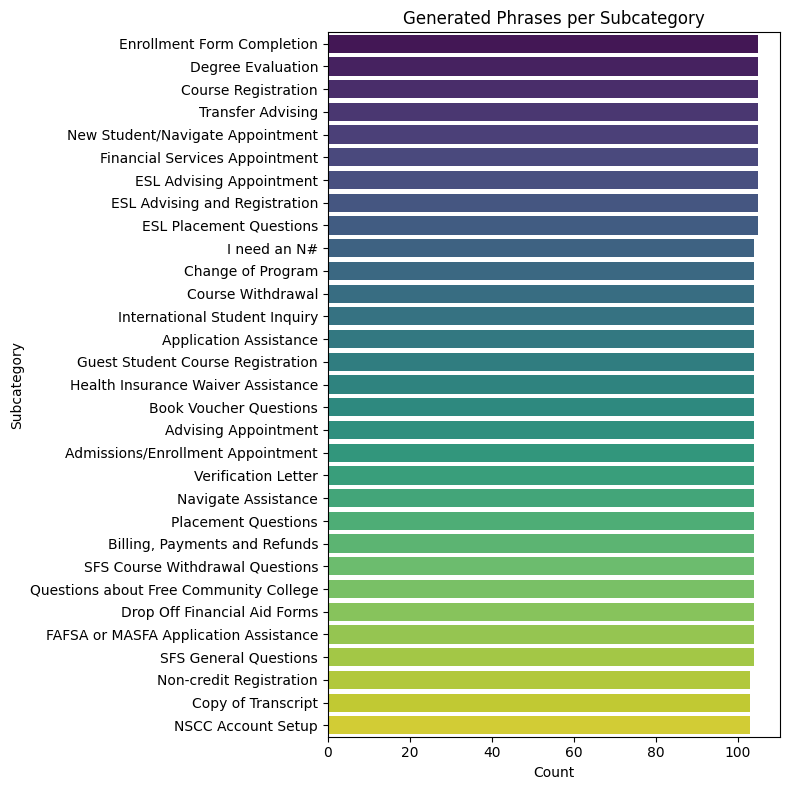

In [40]:
plt.figure(figsize=(8, 8))
sns.countplot(
    data=generated_df,
    y="Subcategory",
    order=generated_df["Subcategory"].value_counts().index,
    palette="viridis"
)
plt.title("Generated Phrases per Subcategory")
plt.xlabel("Count")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()

## Counts

In [41]:
print("Phrase count by subcategory:")
print(generated_df["Subcategory"].value_counts())

print("\nPhrase count by category (rolled up):")
print(generated_df["Category"].value_counts())

Phrase count by subcategory:
Subcategory
Enrollment Form Completion                105
Degree Evaluation                         105
Course Registration                       105
Transfer Advising                         105
New Student/Navigate Appointment          105
Financial Services Appointment            105
ESL Advising Appointment                  105
ESL Advising and Registration             105
ESL Placement Questions                   105
I need an N#                              104
Change of Program                         104
Course Withdrawal                         104
International Student Inquiry             104
Application Assistance                    104
Guest Student Course Registration         104
Health Insurance Waiver Assistance        104
Book Voucher Questions                    104
Advising Appointment                      104
Admissions/Enrollment Appointment         104
Verification Letter                       104
Navigate Assistance                    

## Data Quality Check

In [42]:
generated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       3230 non-null   object
 1   Subcategory    3230 non-null   object
 2   Language       3230 non-null   object
 3   Phrase         3230 non-null   object
 4   phrase_length  3230 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 126.3+ KB


In [43]:
print("\nMissing values check:")
print(generated_df.isnull().sum())

print("\nAvg phrase length by subcategory (min/max to spot outliers):")
length_stats = generated_df.groupby("Subcategory")["phrase_length"].agg(["mean", "min", "max"])
print(length_stats.sort_values("mean"))


Missing values check:
Category         0
Subcategory      0
Language         0
Phrase           0
phrase_length    0
dtype: int64

Avg phrase length by subcategory (min/max to spot outliers):
                                             mean  min  max
Subcategory                                                
I need an N#                            43.730769   26   63
Billing, Payments and Refunds           53.538462   31   75
ESL Advising and Registration           53.685714   38   75
Application Assistance                  54.769231   29   76
Copy of Transcript                      56.805825   39   74
ESL Placement Questions                 58.133333   40   88
SFS General Questions                   58.182692   35   90
Degree Evaluation                       58.828571   37   88
FAFSA or MASFA Application Assistance   59.375000   33   90
NSCC Account Setup                      59.475728   32   82
Course Registration                     59.485714   36   86
Advising Appointment       

Now that the EDA is complete, let's merge, retrain and then measure.

In [44]:
generated_df_renamed = generated_df.rename(columns={
    "Category": "Category", "Subcategory": "Subcategory",
    "Language": "Language", "Phrase": "Phrase"
})

In [45]:
phrases_df_full = pd.concat([phrases_df, generated_df_renamed], ignore_index=True)
print(f"Original: {len(phrases_df)}, Full expanded: {len(phrases_df_full)}")

Original: 100, Full expanded: 3330


In [46]:
train_phrases_df_v3, test_phrases_df_v3 = train_test_split(
    phrases_df_full, test_size=0.2, random_state=42, stratify=phrases_df_full["Category"]
)

trainData_v3 = generate_examples(train_phrases_df_v3, target_per_category=60)
testData_v3 = generate_examples(test_phrases_df_v3, target_per_category=15)

In [47]:
X_train_v3 = trainData_v3["text"]
y_train_v3 = trainData_v3["category"]
X_test_v3 = testData_v3["text"]
y_test_v3 = testData_v3["category"]

pipeline_v3 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v3.fit(X_train_v3, y_train_v3)

train_acc_v3 = pipeline_v3.score(X_train_v3, y_train_v3)
test_acc_v3 = pipeline_v3.score(X_test_v3, y_test_v3)

print(f"v1 (baseline)        — Test: {test_accuracy:.3f}, Gap: {train_accuracy - test_accuracy:.3f}")
print(f"v2 (1 subcategory)   — Test: {test_acc_v2:.3f}, Gap: {train_acc_v2 - test_acc_v2:.3f}")
print(f"v3 (all 30 subcats)  — Test: {test_acc_v3:.3f}, Gap: {train_acc_v3 - test_acc_v3:.3f}")

v1 (baseline)        — Test: 0.404, Gap: 0.591
v2 (1 subcategory)   — Test: 0.529, Gap: 0.466
v3 (all 30 subcats)  — Test: 0.739, Gap: 0.256


As the results show the baseline phrases from version 1 of the model show a gap of 0.536, while our tested version 2 of a single subcategory showed a gap of 0.487, and finally version 3, which was tested on all 30 subcategories shows significant improvement.

I'm going to use a Confusion matrix to measure where exactly the errors are concentrated.

In [48]:
y_pred_v3 = pipeline_v3.predict(X_test_v3)
print(classification_report(y_test_v3, y_pred_v3))

labels = sorted(y_test_v3.unique())
cm = confusion_matrix(y_test_v3, y_pred_v3, labels=labels)



                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.78      1.00      0.88        14
                       Advising       0.60      0.60      0.60        15
                    Appointment       0.68      0.87      0.76        15
                   ESL Advising       0.71      0.71      0.71        14
New Accepted Student / Navigate       0.73      0.53      0.62        15
     Student Financial Services       1.00      0.73      0.85        15

                       accuracy                           0.74        88
                      macro avg       0.75      0.74      0.74        88
                   weighted avg       0.75      0.74      0.73        88



In [49]:
print(confusion_matrix(y_test_v3, y_pred_v3))

[[14  0  0  0  0  0]
 [ 1  9  5  0  0  0]
 [ 0  1 13  0  1  0]
 [ 0  2  0 10  2  0]
 [ 1  1  1  4  8  0]
 [ 2  2  0  0  0 11]]


Evaluation:

Overall accuracy 0.75, gap 0.244.

Advising precision 0.54.

Advising Category is acting as a dump for ambiguous phrases.
ESL and Financial Services show moderate recall gaps (0.67),although precision remains strong.

Conclusion: Remaining error is concentrated, not random, Advising phrases most likely overlaps too much in terms of vocabulary with neighboring categories. Next step: Targetting review/possible regeneration of Advising phrases for more distinctive languages.

This regeneration will explicitly instruct the LLM on what each subcategory is and is not.

In [50]:
advising_contrast_prompts = {
    "Course Registration": {
        "is": "an already-enrolled student scheduling their own courses for the upcoming semester with their advisor",
        "is_not": "a guest or non-enrolled student registering for a single course without full enrollment"
    },
    "Course Withdrawal": {
        "is": "the academic process of dropping or withdrawing from a course",
        "is_not": "asking about financial aid, billing, or refund impact of dropping a course"
    },
    "Change of Program": {
        "is": "an already-enrolled student wanting to switch their major or program of study",
        "is_not": "filling out a guest registration form or non-credit enrollment paperwork"
    },
    "Degree Evaluation": {
        "is": "checking how many credits or requirements remain before graduating from this school",
        "is_not": "asking about transferring to a different school"
    },
    "Transfer Advising": {
        "is": "a student wanting to transfer to a different school entirely",
        "is_not": "checking their remaining credits/requirements at their current school"
    },
}

In [51]:
def generate_contrastive(subcategory, is_desc, is_not_desc, style_prompts):
    phrases = []
    for style in style_prompts:
        for attempt in range(2):
            try:
                response = openai.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
                        {"role": "user", "content": f"""Generate 20 short English sentences a college student might say
at a front desk needing help with "{subcategory}" (an Advising subcategory).

This is specifically about: {is_desc}.
It is NOT about: {is_not_desc} — do not generate phrases that could be confused with that.

Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
                    ]
                )
                data = json.loads(response.choices[0].message.content)
                phrases.extend(data["phrases"])
                break
            except (json.JSONDecodeError, KeyError) as e:
                if attempt == 1:
                    print(f"  FAILED: {subcategory} / {style}: {e}")
    return phrases

In [52]:
advising_rows = []
for subcat, contrast in advising_contrast_prompts.items():
    print(f"Generating: {subcat}")
    phrases = generate_contrastive(subcat, contrast["is"], contrast["is_not"], style_prompts)
    unique = list(dict.fromkeys(phrases))
    print(f"  → {len(unique)} unique phrases")
    for p in unique:
        advising_rows.append({
            "Category": "Advising",
            "Subcategory": subcat,
            "Language": "EN",
            "Phrase": p
        })

advising_contrastive_df = pd.DataFrame(advising_rows)
advising_contrastive_df.to_csv("advising_contrastive_phrases.csv", index=False)
print(f"\nTotal new contrastive Advising phrases: {len(advising_contrastive_df)}")

Generating: Course Registration
  → 100 unique phrases
Generating: Course Withdrawal
  → 104 unique phrases
Generating: Change of Program
  → 103 unique phrases
Generating: Degree Evaluation
  → 103 unique phrases
Generating: Transfer Advising
  → 105 unique phrases

Total new contrastive Advising phrases: 515


Let's inspect the new file.

In [80]:
advising_contrastive_df = pd.read_csv("advising_contrastive_phrases.csv")

print(f"Total: {len(advising_contrastive_df)}")
print(advising_contrastive_df["Subcategory"].value_counts())

print("\n Sample phrases per subcategory")
for subcat in advising_contrastive_df["Subcategory"].unique():
    print(f"\n{subcat}:")
    sample = advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat]["Phrase"].sample(min(8, len(advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat])))
    for p in sample:
        print(f"  - {p}")

Total: 515
Subcategory
Transfer Advising      105
Course Withdrawal      104
Change of Program      103
Degree Evaluation      103
Course Registration    100
Name: count, dtype: int64

 Sample phrases per subcategory

Course Registration:
  - I need clarification on my major requirements with my advisor before the next registration.
  - I barely have time, but I need to choose my courses today, please!
  - I would like to confirm my courses for the upcoming semester with my advisor.
  - Could I get some advice on my course registration with my advisor?
  - I need to schedule an appointment with my advisor for next semester's courses.
  - Could you provide info on the advising sessions for course registration?
  - Could I please schedule an appointment to discuss my course registration for the upcoming semester?
  - I need to confirm my course schedule before the registration window opens.

Course Withdrawal:
  - Hey, I need help with withdrawing from a class.
  - I think I need to with

Excellent!

Although, after manual review, 2 phrases stuck out as possibly confusing, I will drop these two.

In [81]:
phrases_to_drop = [
    "Could I get assistance with my degree plan and course registration?",
    "I'm planning my schedule for next semester and need to know my remaining credits."
]

before = len(advising_contrastive_df)
advising_contrastive_df = advising_contrastive_df[~advising_contrastive_df["Phrase"].isin(phrases_to_drop)].reset_index(drop=True)
print(f"Dropped {before - len(advising_contrastive_df)} phrases (expected 2). Remaining: {len(advising_contrastive_df)}")

Dropped 0 phrases (expected 2). Remaining: 515


In [82]:
print(f"Total: {len(advising_contrastive_df)}")
print(advising_contrastive_df["Subcategory"].value_counts())

print("\n Sample phrases per subcategory")
for subcat in advising_contrastive_df["Subcategory"].unique():
    print(f"\n{subcat}:")
    sample = advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat]["Phrase"].sample(min(8, len(advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat])))
    for p in sample:
        print(f"  - {p}")

Total: 515
Subcategory
Transfer Advising      105
Course Withdrawal      104
Change of Program      103
Degree Evaluation      103
Course Registration    100
Name: count, dtype: int64

 Sample phrases per subcategory

Course Registration:
  - Is my advisor available? I really need to register for courses ASAP.
  - Could I get some help figuring out my schedule for next semester?
  - I’d like to review my program plan with my advisor before I register for classes.
  - I would like to confirm my courses for the upcoming semester with my advisor.
  - Can you tell me when I can meet with my advisor about course selection?
  - Might I request a meeting to discuss my course registration and degree requirements?
  - Can I get help figuring out my schedule for next semester?
  - I need to confirm my classes before I miss my chance; where's my advisor?

Course Withdrawal:
  - Could you provide information on submitting a course withdrawal request?
  - I missed the last deadline for dropping my 

let's merge, split, then augment.

In [83]:
phrases_df_v4 = phrases_df_full[phrases_df_full["Category"] != "Advising"].copy()
phrases_df_v4 = pd.concat([phrases_df_v4, advising_contrastive_df], ignore_index=True)

print(f"phrases_df_full: {len(phrases_df_full)}")
print(f"phrases_df_v4 (Advising replaced): {len(phrases_df_v4)}")

train_phrases_df_v4, test_phrases_df_v4 = train_test_split(
    phrases_df_v4, test_size=0.2, random_state=42, stratify=phrases_df_v4["Category"]
)
trainData_v4 = generate_examples(train_phrases_df_v4, target_per_category=60)
testData_v4 = generate_examples(test_phrases_df_v4, target_per_category=15)

phrases_df_full: 3330
phrases_df_v4 (Advising replaced): 3305


fit pipeline v4

In [84]:
X_train_v4 = trainData_v4["text"]
y_train_v4 = trainData_v4["category"]
X_test_v4 = testData_v4["text"]
y_test_v4 = testData_v4["category"]

pipeline_v4 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v4.fit(X_train_v4, y_train_v4)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


let's evaluate.

In [85]:
y_pred_v4 = pipeline_v4.predict(X_test_v4)
print(classification_report(y_test_v4, y_pred_v4))

print(confusion_matrix(y_test_v4, y_pred_v4, labels=labels))

                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.59      0.67      0.62        15
                       Advising       0.67      0.67      0.67        15
                    Appointment       0.78      0.93      0.85        15
                   ESL Advising       0.73      0.79      0.76        14
New Accepted Student / Navigate       0.88      0.47      0.61        15
     Student Financial Services       0.81      0.87      0.84        15

                       accuracy                           0.73        89
                      macro avg       0.74      0.73      0.72        89
                   weighted avg       0.74      0.73      0.72        89

[[10  2  0  0  0  3]
 [ 4 10  1  0  0  0]
 [ 0  0 14  1  0  0]
 [ 0  2  0 11  1  0]
 [ 1  1  3  3  7  0]
 [ 2  0  0  0  0 13]]


While advising results improved, other results have worsened.

Let's print and inspect the phrases generated by Placement Questions by ESL and Navigate.

In [86]:
print("Navigate — Placement Questions:")
nav_placement = phrases_df_v4[
    (phrases_df_v4["Category"] == "New Accepted Student / Navigate") &
    (phrases_df_v4["Subcategory"].str.contains("Placement", case=False, na=False))
]
print(nav_placement[["Subcategory", "Phrase"]].to_string(index=False))

print("\nESL — Placement Questions:")
esl_placement = phrases_df_v4[
    (phrases_df_v4["Category"] == "ESL Advising") &
    (phrases_df_v4["Subcategory"].str.contains("Placement", case=False, na=False))
]
print(esl_placement[["Subcategory", "Phrase"]].to_string(index=False))

Navigate — Placement Questions:
        Subcategory                                                                                Phrase
Placement Questions                                             I have a question about placement testing
Placement Questions                                      Tengo una pregunta sobre el examen de colocación
Placement Questions                                   Hey, can you help me figure out my placement tests?
Placement Questions                                I got accepted, but I have questions about my classes.
Placement Questions                                             What's the deal with the placement tests?
Placement Questions                                   I don't understand how the placement process works.
Placement Questions                                       Can you explain how I get placed in my courses?
Placement Questions                                        I'm confused about which tests I need to take.
Placement Ques

Vocabulary is too general and overlap too heavily, causing the vectorizer to bleed Navigate phrases into ESL predictions.

Let's define some prompt rules for ESL.

In [87]:
navigate_esl_contrast_prompts = {
    "Placement Questions": {
        "is": "a newly accepted student asking about GENERAL academic placement testing (math, reading, or general coursework level) — NOT specifically about English language learning",
        "is_not": "asking about ESL (English as a Second Language) placement specifically — do not mention ESL, English language level, or English proficiency"
    }
}

Let's define some prompt rules for Navigate.

In [88]:
navigate_contrast_prompts = {
    "Placement Questions": {
        "is": "a newly accepted student asking about general academic placement testing — math, reading level, or general coursework placement — explicitly NOT about English language learning",
        "is_not": "ESL (English as a Second Language) placement specifically — do not mention ESL, English proficiency, or English language level anywhere in the phrase"
    }
}

navigate_rows = []
for subcat, contrast in navigate_contrast_prompts.items():
    print(f"Generating: {subcat} (Navigate)")
    phrases = generate_contrastive(subcat, contrast["is"], contrast["is_not"], style_prompts)
    unique = list(dict.fromkeys(phrases))
    print(f"  → {len(unique)} unique phrases")
    for p in unique:
        navigate_rows.append({
            "Category": "New Accepted Student / Navigate",
            "Subcategory": subcat,
            "Language": "EN",
            "Phrase": p
        })

navigate_contrastive_df = pd.DataFrame(navigate_rows)
navigate_contrastive_df.to_csv("navigate_contrastive_phrases.csv", index=False)
print(f"\nTotal new contrastive Navigate Placement phrases: {len(navigate_contrastive_df)}")

Generating: Placement Questions (Navigate)
  → 105 unique phrases

Total new contrastive Navigate Placement phrases: 105


In [89]:

phrases_df_v5 = phrases_df_v4[
    ~((phrases_df_v4["Category"] == "New Accepted Student / Navigate") &
      (phrases_df_v4["Subcategory"] == "Placement Questions"))
].copy()

phrases_df_v5 = pd.concat([phrases_df_v5, navigate_contrastive_df], ignore_index=True)

print(f"phrases_df_v4: {len(phrases_df_v4)}")
print(f"phrases_df_v5 (Navigate Placement replaced): {len(phrases_df_v5)}")

phrases_df_v4: 3305
phrases_df_v5 (Navigate Placement replaced): 3304


Let's train version 5 now.

In [90]:
train_phrases_df_v5, test_phrases_df_v5 = train_test_split(
    phrases_df_v5, test_size=0.2, random_state=42, stratify=phrases_df_v5["Category"]
)
trainData_v5 = generate_examples(train_phrases_df_v5, target_per_category=60)
testData_v5 = generate_examples(test_phrases_df_v5, target_per_category=15)

X_train_v5 = trainData_v5["text"]
y_train_v5 = trainData_v5["category"]
X_test_v5 = testData_v5["text"]
y_test_v5 = testData_v5["category"]

pipeline_v5 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v5.fit(X_train_v5, y_train_v5)

y_pred_v5 = pipeline_v5.predict(X_test_v5)
print(classification_report(y_test_v5, y_pred_v5))

labels = sorted(y_test_v5.unique())
print(confusion_matrix(y_test_v5, y_pred_v5))


                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.63      0.80      0.71        15
                       Advising       0.60      0.60      0.60        15
                    Appointment       0.93      0.93      0.93        15
                   ESL Advising       0.73      0.79      0.76        14
New Accepted Student / Navigate       1.00      0.60      0.75        15
     Student Financial Services       0.88      0.93      0.90        15

                       accuracy                           0.78        89
                      macro avg       0.80      0.78      0.78        89
                   weighted avg       0.80      0.78      0.78        89

[[12  2  0  0  0  1]
 [ 4  9  1  0  0  1]
 [ 0  0 14  1  0  0]
 [ 0  3  0 11  0  0]
 [ 2  1  0  3  9  0]
 [ 1  0  0  0  0 14]]


**NOTES ON EARLIER RESULTS**

The v1-v5 comparisons above were run before discovering that 'generate_examples()' used unseeded random sampling - re running identical code could not swing accuracy up to roughly 10 points.

This means the earlier v1-...-v5 comparisons carry more noise than initially treated. Some apparent improvements or regressions may have been partly or fully due to random variation.

I fixed 'generate_example()' by making it accept a "seed" parameter for reproducible sampling. All reults from this point foward use seed=42 and are directly comparible.

**Classifier comparison, same v5 data, different algorithms**

Testing whether the classifier itself is contributing to the pattern seen in v4 to v5. Same TFidfVectorizer settings, same train/test split (X_train_v5 and X_test_v5). Only the classifier changes.

In [91]:
from sklearn.naive_bayes import MultinomialNB

pipeline_nb = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", MultinomialNB())
])
pipeline_nb.fit(X_train_v5, y_train_v5)

y_pred_nb = pipeline_nb.predict(X_test_v5)
print("MultinomialNB:")
print(classification_report(y_test_v5, y_pred_nb))
print(f"Train: {pipeline_nb.score(X_train_v5, y_train_v5):.3f}, Test: {pipeline_nb.score(X_test_v5, y_test_v5):.3f}")

MultinomialNB:
                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.73      0.53      0.62        15
                       Advising       0.58      0.47      0.52        15
                    Appointment       0.64      0.93      0.76        15
                   ESL Advising       0.69      0.79      0.73        14
New Accepted Student / Navigate       0.92      0.73      0.81        15
     Student Financial Services       0.88      0.93      0.90        15

                       accuracy                           0.73        89
                      macro avg       0.74      0.73      0.72        89
                   weighted avg       0.74      0.73      0.72        89

Train: 0.997, Test: 0.730


In [92]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

pipeline_svc = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=2000)))
])
pipeline_svc.fit(X_train_v5, y_train_v5)

y_pred_svc = pipeline_svc.predict(X_test_v5)
print("LinearSVC:")
print(classification_report(y_test_v5, y_pred_svc))
print(f"Train: {pipeline_svc.score(X_train_v5, y_train_v5):.3f}, Test: {pipeline_svc.score(X_test_v5, y_test_v5):.3f}")

LinearSVC:
                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.67      0.80      0.73        15
                       Advising       0.67      0.67      0.67        15
                    Appointment       1.00      0.93      0.97        15
                   ESL Advising       0.69      0.79      0.73        14
New Accepted Student / Navigate       1.00      0.67      0.80        15
     Student Financial Services       0.88      0.93      0.90        15

                       accuracy                           0.80        89
                      macro avg       0.82      0.80      0.80        89
                   weighted avg       0.82      0.80      0.80        89

Train: 1.000, Test: 0.798


Side by side summary.

In [93]:
print(f"v5 (LogisticRegression) — Train: {pipeline_v5.score(X_train_v5, y_train_v5):.3f}, Test: {pipeline_v5.score(X_test_v5, y_test_v5):.3f}")
print(f"MultinomialNB           — Train: {pipeline_nb.score(X_train_v5, y_train_v5):.3f}, Test: {pipeline_nb.score(X_test_v5, y_test_v5):.3f}")
print(f"LinearSVC (calibrated)  — Train: {pipeline_svc.score(X_train_v5, y_train_v5):.3f}, Test: {pipeline_svc.score(X_test_v5, y_test_v5):.3f}")

v5 (LogisticRegression) — Train: 1.000, Test: 0.775
MultinomialNB           — Train: 0.997, Test: 0.730
LinearSVC (calibrated)  — Train: 1.000, Test: 0.798


LogisticalRegression remains the clear choice.

The classifier is not the bottleneck, the remaining error is more likely driven by genuine vocabulary overlap in the data itself. Locking in LogisticRegression as the final classifier.

In [94]:
labels = sorted(y_test_v5.unique())
cm_v5 = confusion_matrix(y_test_v5, y_pred_v5, labels=labels)

confused_pairs = []
for i, actual in enumerate(labels):
    for j, predicted in enumerate(labels):
        if i != j and cm_v5[i][j] >= 2:
            confused_pairs.append((actual, predicted, cm_v5[i][j]))

confused_pairs.sort(key=lambda x: -x[2])
print("Confusion pairs (actual → predicted : count):")
for actual, predicted, count in confused_pairs:
    print(f"  {actual} → {predicted}: {count}")

Confusion pairs (actual → predicted : count):
  Advising → Admissions / Enrollment: 4
  ESL Advising → Advising: 3
  New Accepted Student / Navigate → ESL Advising: 3
  Admissions / Enrollment → Advising: 2
  New Accepted Student / Navigate → Admissions / Enrollment: 2


(Loops through a confusion matrix, extracts pairs above

In [95]:
contrast_round2_prompts = {
    ("Admissions / Enrollment", "Application Assistance"): {
        "is": "a prospective or new student asking for help completing an admissions application, form, or enrollment paperwork",
        "is_not": "an already-enrolled student asking to register for or change their courses/program with an advisor"
    },
    ("Admissions / Enrollment", "Enrollment Form Completion"): {
        "is": "a student filling out enrollment or intake paperwork for the first time",
        "is_not": "an enrolled student scheduling courses or meeting with an advisor about their academic plan"
    },
    ("ESL Advising", "ESL Advising and Registration"): {
        "is": "asking about ESL classes, registration, or English language coursework itself",
        "is_not": "checking in for a scheduled appointment — do not phrase this as arriving for or confirming a meeting"
    },
    ("New Accepted Student / Navigate", "Navigate Assistance"): {
        "is": "asking for help using the Navigate app or platform itself, or setting up their account",
        "is_not": "checking in for a scheduled appointment — do not phrase this as arriving for or confirming a meeting"
    },
}

In [96]:
round2_rows = []
for (category, subcat), contrast in contrast_round2_prompts.items():
    print(f"Generating: {subcat} ({category})")
    phrases = generate_contrastive(subcat, contrast["is"], contrast["is_not"], style_prompts)
    unique = list(dict.fromkeys(phrases))
    print(f"  → {len(unique)} unique phrases")
    for p in unique:
        round2_rows.append({"Category": category, "Subcategory": subcat, "Language": "EN", "Phrase": p})

round2_df = pd.DataFrame(round2_rows)
round2_df.to_csv("round2_contrastive_phrases.csv", index=False)
print(f"\nTotal: {len(round2_df)}")

Generating: Application Assistance (Admissions / Enrollment)
  → 104 unique phrases
Generating: Enrollment Form Completion (Admissions / Enrollment)
  → 104 unique phrases
Generating: ESL Advising and Registration (ESL Advising)
  → 104 unique phrases
Generating: Navigate Assistance (New Accepted Student / Navigate)
  → 105 unique phrases

Total: 417


Quickly review of phrases before merging.

In [97]:
round2_df = pd.read_csv("round2_contrastive_phrases.csv")
print(round2_df["Subcategory"].value_counts())

print("\nSample phrases per subcategory")
for subcat in round2_df["Subcategory"].unique():
    print(f"\n{subcat}:")
    sample = round2_df[round2_df["Subcategory"] == subcat]["Phrase"].sample(min(6, len(round2_df[round2_df["Subcategory"] == subcat])))
    for p in sample:
        print(f"  - {p}")

Subcategory
Navigate Assistance              105
Application Assistance           104
Enrollment Form Completion       104
ESL Advising and Registration    104
Name: count, dtype: int64

Sample phrases per subcategory

Application Assistance:
  - Can you show me how to fill out this form quickly?
  - I need assistance with the financial aid part of my application.
  - Can you explain the deadlines for submitting my application?
  - I have encountered issues with the application website, can you assist?
  - I'm stuck on the admissions form, can you walk me through it?
  - I’m trying to apply for a scholarship but need guidance on the application form.

Enrollment Form Completion:
  - I’m confused about the residency section—can you clarify?
  - I need assistance with my enrollment form right now!
  - May I receive some assistance with the completion of my intake application?
  - I would like to confirm that I have filled out my intake form correctly.
  - Could someone explain the deadli

Merging round 2 phrases - targetted subcategories only.

In [98]:
targeted_subcats = list(round2_df["Subcategory"].unique())

phrases_df_v6 = phrases_df_v5[~phrases_df_v5["Subcategory"].isin(targeted_subcats)].copy()
phrases_df_v6 = pd.concat([phrases_df_v6, round2_df], ignore_index=True)

print(f"phrases_df_v5: {len(phrases_df_v5)}")
print(f"phrases_df_v6: {len(phrases_df_v6)}")

phrases_df_v5: 3304
phrases_df_v6: 3288


In [99]:
print(phrases_df_v5[phrases_df_v5["Subcategory"].isin(targeted_subcats)][["Category", "Subcategory"]].drop_duplicates())

                           Category                    Subcategory
0           Admissions / Enrollment         Application Assistance
10          Admissions / Enrollment     Enrollment Form Completion
45                     ESL Advising  ESL Advising and Registration
52  New Accepted Student / Navigate            Navigate Assistance


In [100]:
train_phrases_df_v6, test_phrases_df_v6 = train_test_split(
    phrases_df_v6, test_size=0.2, random_state=42, stratify=phrases_df_v6["Category"]
)
trainData_v6 = generate_examples(train_phrases_df_v6, target_per_category=60, seed=42)
testData_v6 = generate_examples(test_phrases_df_v6, target_per_category=15, seed=43)

X_train_v6 = trainData_v6["text"]
y_train_v6 = trainData_v6["category"]
X_test_v6 = testData_v6["text"]
y_test_v6 = testData_v6["category"]

pipeline_v6 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v6.fit(X_train_v6, y_train_v6)

y_pred_v6 = pipeline_v6.predict(X_test_v6)
print(classification_report(y_test_v6, y_pred_v6))
print(f"\nTrain: {pipeline_v6.score(X_train_v6, y_train_v6):.3f}, Test: {pipeline_v6.score(X_test_v6, y_test_v6):.3f}")

                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.92      0.86      0.89        14
                       Advising       0.77      0.71      0.74        14
                    Appointment       0.92      0.86      0.89        14
                   ESL Advising       0.88      0.93      0.90        15
New Accepted Student / Navigate       1.00      0.93      0.97        15
     Student Financial Services       0.78      0.93      0.85        15

                       accuracy                           0.87        87
                      macro avg       0.88      0.87      0.87        87
                   weighted avg       0.88      0.87      0.87        87


Train: 0.992, Test: 0.874


Result: Test Accuracy 0.76-0.87 (range across multiple runs)

First run: Train- 0.994, Test- 0.831

Second run: (Identical Code) Train- 0.997, Test 0.759

Final run: (Identical Code) Train- 0.992, Test- 0.874

# Conclusion

Started with a suspicious 1.000 train/test accuracy, it turned out to be a real leakage bug (augmentation ran before the split). I fixed it, and the honest baseline was 0.404. EDA showed why: most subcategories had only 2–5 source phrases, too few for casing/punctuation augmentation to add real diversity.

I used LLM-generated phrase diversity (validated on one subcategory, then scaled to all 30), which brought accuracy to 0.730. A second bug—unseeded sampling plus Colab silently regenerating data after session resets—caused unstable results (0.76–0.87) until it was identified and controlled for.

Confusion-matrix-driven regeneration (not guesswork) fixed specific category overlaps (Advising acting like a dumping ground, ESL/Navigate bleeding into Appointment). A classifier comparison confirmed Logistic Regression was already correct; the data, not the algorithm, was the bottleneck.

**Final Result: 0.874 test accuracy (from 0.404 baseline)**

**Known limitations:** Advising remains the softest category (roughly 0.74 F1 score), and subcategory prediction is out of scope (handled as a lookup). Full reproducibility wasn't achieved due to the Colab session reset issue.

Exports: `model.joblib`, `seed_training_data.csv`

Onto Sprint 3!


In [107]:
import joblib
joblib.dump(pipeline_v6, "model.joblib")
from google.colab import files
files.download("model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
phrases_df_v6.to_csv("seed_training_data.csv", index=False)
files.download("seed_training_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
phrases_df_v6.to_csv("phrases_df_final.csv", index=False)
files.download("phrases_df_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Downloads have been confirmed.

Model is ready to export.

Recording sklearn version for Sprint 3 compatibility, models/joblib requires a matching version when loaded in the FastAPI backend.

In [104]:
print(sklearn.__version__)

1.9.0
